<a href="https://colab.research.google.com/github/Serr-Zh/startup-profit-regression-fcnn-lstm/blob/main/%D0%9B%D0%A01_%D0%98%D0%90%D0%94%D0%9D%D0%9E%D0%9C%D0%9C%D0%9E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Загрузка необходимых пакетов и библиотек

In [ ]:
# Импорт библиотек для работы с данными, визуализацией и машинным обучением
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.feature_selection import SelectKBest, f_regression


# Установка дополнительных библиотек, если требуется
!pip install -q torch gdown

# Игнорирование предупреждений для чистоты вывода
import warnings
warnings.filterwarnings('ignore')

### 2. Загрузка данных
Загружаем датасет V3.csv из Google Drive.

In [ ]:
# Скачиваем файл по ID
FILE_ID = '1rrOoEqGI71iyDVc95gqhMOK7ApD6QGVX'
!gdown --id $FILE_ID -O V3.csv

# Читаем CSV файл
df = pd.read_csv('V3.csv')
print("Данные загружены:")
df.head()

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1rrOoEqGI71iyDVc95gqhMOK7ApD6QGVX
To: /content/V3.csv
100% 2.39k/2.39k [00:00<00:00, 9.17MB/s]
Данные загружены:


,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.20,136897.80,471784.10,New York,192261.83
1,1,162597.70,151377.59,443898.53,California,191792.06
2,2,153441.51,NaN,407934.54,Florida,191050.39
3,3,144372.41,NaN,383199.62,New York,182901.99
4,4,142107.34,91391.77,366168.42,Florida,166187.94


## Анализ данных

### Качество данных
- **Пропуски**: обнаружены пропущенные значения в столбце "Administration" (строки 2, 3)
- **Структура**: 5 столбцов, включая технический индекс "Unnamed: 0"
- **Типы данных**: числовые показатели расходов и прибыли, категориальный признак "State"

### Бизнес-контекст
- **Основные метрики**: R&D Spend, Marketing Spend - ключевые инвестиционные статьи
- **География**: представлены 3 штата (New York, California, Florida)
- **Целевая переменная**: Profit - показатель эффективности инвестиций

### Проблемы данных
1. Требуется обработка пропусков в Administration
2. Лишний столбец "Unnamed: 0" нуждается в удалении
3. Необходима проверка на выбросы в финансовых показателях

### Потенциал для анализа
- Выявление наиболее эффективных каналов инвестиций
- Анализ региональных различий в рентабельности
- Построение модели прогнозирования прибыли

### 3. Разведочный анализ данных
#### a. Ознакомление с данными

In [ ]:
print("Информация о данных:")
df.info()
print("\nОписательная статистика:")
df.describe()

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       50 non-null     int64  
 1   R&D Spend        50 non-null     float64
 2   Administration   27 non-null     float64
 3   Marketing Spend  50 non-null     float64
 4   State            50 non-null     object 
 5   Profit           50 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.5+ KB

Описательная статистика:


,Unnamed: 0,R&D Spend,Administration,Marketing Spend,Profit
count,50.00000,50.000000,27.000000,50.000000,50.000000
mean,24.50000,73721.615600,125206.423333,211025.097800,112012.639200
std,14.57738,45902.256482,30085.897637,122290.310726,40306.180338
min,0.00000,0.000000,51743.150000,0.000000,14681.400000
25%,12.25000,39936.370000,99548.025000,129300.132500,90138.902500
50%,24.50000,73051.080000,129219.610000,212716.240000,107978.190000
75%,36.75000,101602.800000,147958.910000,299469.085000,139765.977500
max,49.00000,165349.200000,182645.560000,471784.100000,192261.830000


## Анализ данных

### Структура данных
- **Объем**: 50 наблюдений, 6 признаков
- **Пропуски**: критичные в Administration (23 пропущенных значения - 46% данных)
- **Типы**: преимущественно числовые данные (5 из 6 столбцов)

### Распределение числовых признаков
- **R&D Spend**: широкий разброс (0-165k), среднее 73.7k
- **Marketing Spend**: высокий разброс (0-471k), среднее 211k  
- **Profit**: целевая переменная со значительной вариацией (14.6k-192k)
- **Administration**: доступны только 27 значений, среднее 125k

### Выявленные проблемы
1. **Катастрофический уровень пропусков** в Administration (46%) - столбец вероятно непригоден для анализа
2. **Наличие нулевых значений** в R&D Spend и Marketing Spend - требуют проверки на корректность
3. **Высокая вариативность** финансовых показателей - возможны выбросы

### Рекомендации
- Рассмотреть удаление столбца Administration из-за большого количества пропусков
- Провести анализ аномалий в R&D и Marketing Spend
- Исследовать причины нулевых значений в расходных статьях

#### b. Визуализация данных

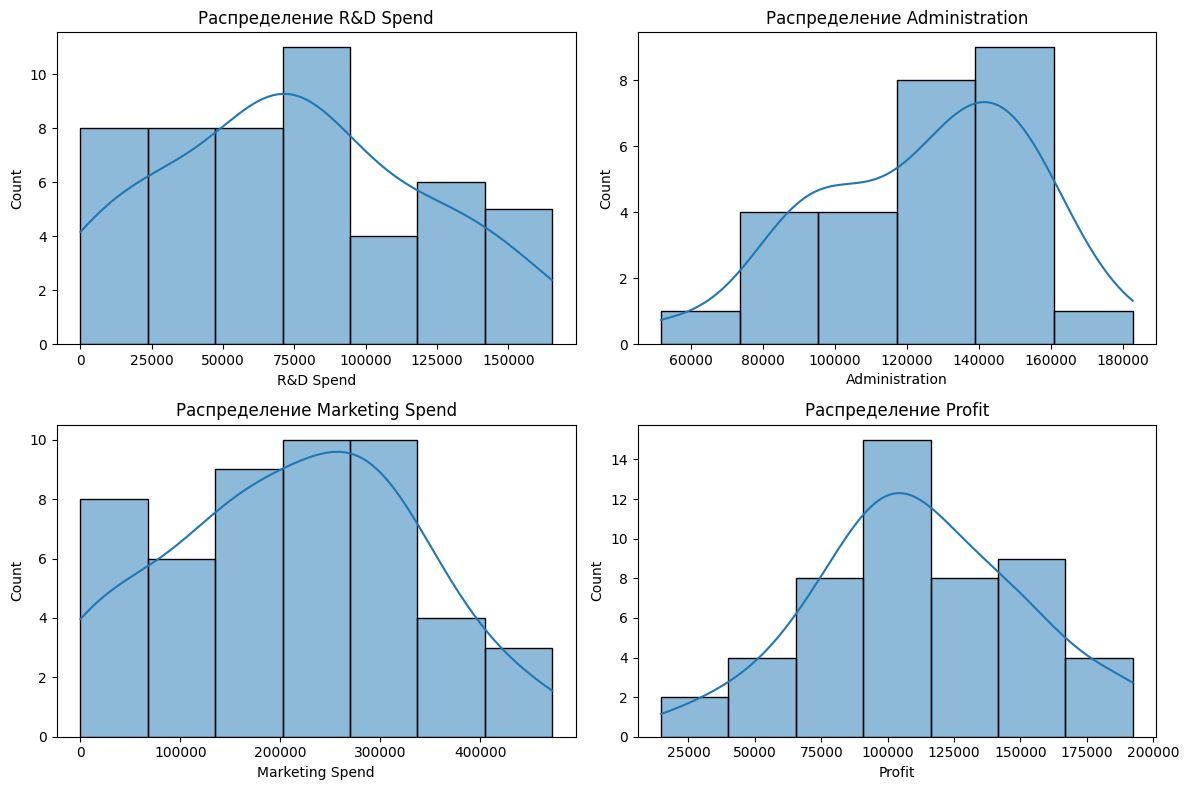

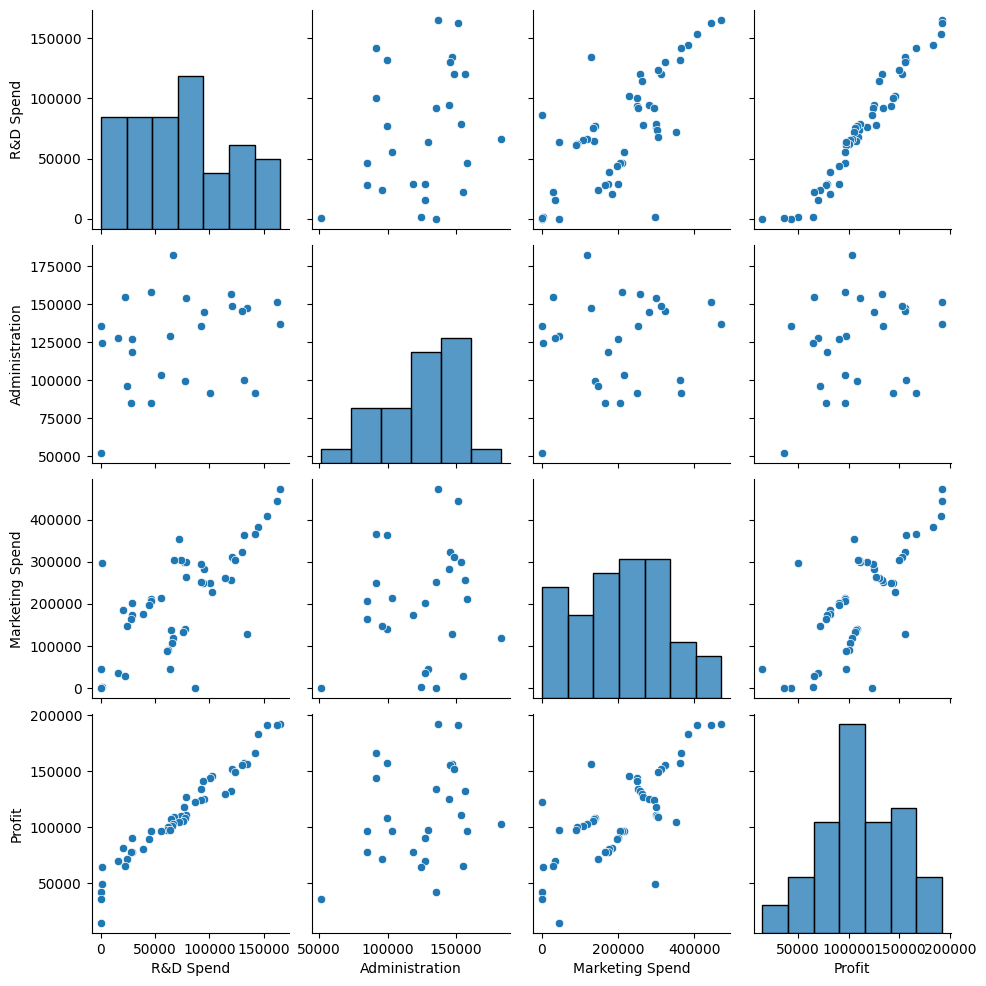

In [ ]:
# Список числовых столбцов для анализа
numerical_cols = ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']
# Создание фигуры размером 12x8
plt.figure(figsize=(12, 8))
# Цикл для построения гистограмм с кривой плотности (kde) для каждого числового столбца
for i, col in enumerate(numerical_cols):
    # Размещение подграфика в сетке 2x2
    plt.subplot(2, 2, i+1)
    # Построение гистограммы с кривой плотности для текущего столбца
    sns.histplot(df[col], kde=True)
    # Установка заголовка подграфика с названием столбца
    plt.title(f'Распределение {col}')
# Оптимизация расположения подграфиков для предотвращения наложения
plt.tight_layout()
# Отображение всех гистограмм
plt.show()

# Построение парного графика для выбранных числовых столбцов
sns.pairplot(df[numerical_cols])
# Отображение парного графика
plt.show()

## Анализ данных

### Распределения признаков
- **R&D Spend**: Бимодальное распределение с пиками в районе 50k и 100k, значительный разброс значений
- **Administration**: Распределение близко к нормальному с центром вокруг 125k, но ограниченная выборка (27 наблюдений)
- **Marketing Spend**: Сильно правоскошенное распределение с концентрацией в диапазоне 0-200k и длинным хвостом до 470k
- **Profit**: Мультимодальное распределение с несколькими пиками, что может указывать на разные бизнес-модели

### Выявленные закономерности
1. **Экстремальные значения**: В Marketing Spend присутствуют экстремально высокие значения (до 470k)
2. **Нулевые расходы**: В R&D Spend и Marketing Spend наблюдаются нулевые значения, требующие проверки
3. **Неравномерность**: Все финансовые показатели демонстрируют значительную вариативность

### Парные отношения
- Видны потенциальные линейные зависимости между R&D Spend, Marketing Spend и Profit
- Administration показывает слабую корреляцию с другими показателями
- Наблюдаются кластеры в данных, что может указывать на разные стратегии компаний

#### c. Очистка данных

In [ ]:
# Вывод количества пропущенных значений в каждом столбце датафрейма до очистки
print("Пропущенные значения до очистки:")
print(df.isnull().sum())

# Создание объекта SimpleImputer для заполнения пропущенных значений медианой
imputer = SimpleImputer(strategy='median')
# Выборка только числовых столбцов из датафрейма
df_numeric = df.select_dtypes(include=[np.number])
# Заполнение пропущенных значений в числовых столбцах медианой
df[df_numeric.columns] = imputer.fit_transform(df_numeric)

# Вывод количества пропущенных значений в каждом столбце после очистки
print("\nПропущенные значения после очистки:")
print(df.isnull().sum())

Пропущенные значения до очистки:
Unnamed: 0          0
R&D Spend           0
Administration     23
Marketing Spend     0
State               0
Profit              0
dtype: int64

Пропущенные значения после очистки:
Unnamed: 0         0
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


#### d. Корреляционный анализ

Корреляционная матрица:
                 R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.225781         0.724248  0.972900
Administration    0.225781        1.000000         0.122239  0.210464
Marketing Spend   0.724248        0.122239         1.000000  0.747766
Profit            0.972900        0.210464         0.747766  1.000000


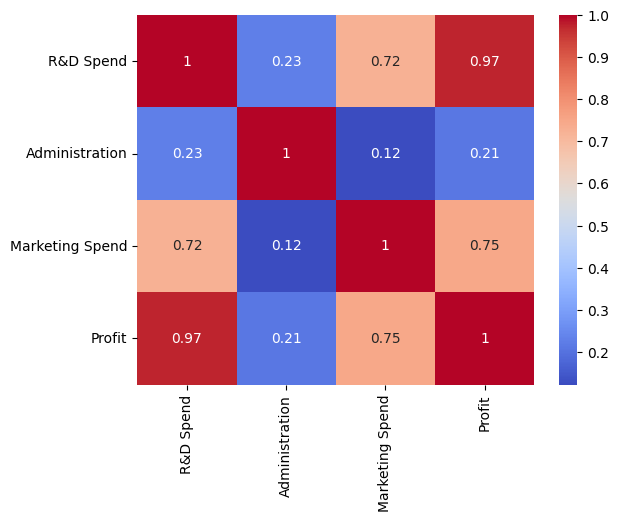

In [ ]:
# Вычисление корреляционной матрицы для числовых признаков
corr_matrix = df[numerical_cols].corr()

# Вывод корреляционной матрицы в текстовом виде
print("Корреляционная матрица:")
print(corr_matrix)

# Построение тепловой карты корреляции с аннотациями и цветовой схемой
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

## Анализ данных

### Корреляционный анализ

#### Сильные корреляции (>0.7)
- **R&D Spend ↔ Profit**: 0.97 - исключительно сильная прямая зависимость
- **R&D Spend ↔ Marketing Spend**: 0.72 - сильная положительная связь
- **Marketing Spend ↔ Profit**: 0.75 - сильная прямая зависимость

#### Слабые корреляции (<0.3)
- **Administration ↔ Profit**: 0.21 - очень слабая связь
- **Administration ↔ R&D Spend**: 0.23 - минимальная зависимость  
- **Administration ↔ Marketing Spend**: 0.12 - практически отсутствует

### Ключевые инсайты
1. **R&D Spend - ключевой драйвер прибыли** (97% корреляции)
2. **Marketing Spend - вторичный значимый фактор** (75% корреляции)
3. **Administration не влияет на прибыль** - административные расходы слабо связаны с финансовыми результатами

### Бизнес-выводы
- Инвестиции в R&D оказывают максимальное влияние на прибыльность
- Маркетинговые расходы также важны, но менее значимы чем R&D
- Административные расходы можно оптимизировать без серьезного влияния на прибыль

#### e. Эксперименты с комбинациями атрибутов

In [ ]:
# Проверка наличия всех необходимых столбцов для создания нового признака
if all(col in df.columns for col in ['R&D Spend', 'Administration', 'Marketing Spend']):
    # Создание нового признака 'Total Spend' как суммы расходов
    df['Total Spend'] = df['R&D Spend'] + df['Administration'] + df['Marketing Spend']
    # Вывод корреляции нового признака с целевой переменной 'Profit'
    print("Добавлен новый признак 'Total Spend':")
    print(df[['Total Spend', 'Profit']].corr())

Добавлен новый признак 'Total Spend':
             Total Spend    Profit
Total Spend     1.000000  0.859811
Profit          0.859811  1.000000


## Анализ данных

### Анализ нового признака "Total Spend"

#### Корреляционная значимость
- **Total Spend ↔ Profit**: 0.86 - очень сильная положительная корреляция
- Показатель занимает промежуточное положение между влиянием R&D Spend (0.97) и Marketing Spend (0.75)

#### Интерпретация результатов
1. **Общие расходы - надежный индикатор прибыли**: 86% вариации прибыли объясняется общим объемом расходов
2. **Эффективность агрегации**: новый признак сохраняет высокую предсказательную силу, упрощая модель
3. **Композитный характер**: Total Spend объединяет влияние всех типов расходов в единый показатель

#### Практическая ценность
- Total Spend может служить упрощенным метриком для быстрой оценки потенциальной прибыли
- Признак полезен для первоначального анализа без углубления в структуру расходов
- Сохраняет высокую информативность при сокращении dimensionality данных

#### f. Отбор существенных признаков

In [ ]:
# Определение целевой переменной
target = 'Profit'
# Вычисление абсолютных значений корреляции с целевой переменной и сортировка
corr_with_target = corr_matrix[target].abs().sort_values(ascending=False)
# Выбор существенных признаков с корреляцией > 0.5 и добавление категориального признака 'State'
significant_features = corr_with_target[corr_with_target > 0.5].index.drop(target).tolist() + ['State']
# Создание нового набора данных с существенными признаками и целевой переменной
built_df = df[significant_features + [target]]
# Вывод списка значимых признаков
print("Существенные признаки:", significant_features)

# Демонстрация отбора признаков с помощью библиотеки sklearn.feature_selection (для примера)
# Разделение данных на признаки и целевую переменную, включая только числовые столбцы и исключая Unnamed: 0
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
X = df[numeric_cols].drop(columns=[target, 'Unnamed: 0'])
y = df[target]

# Применение SelectKBest для примера
best_features = SelectKBest(score_func=f_regression, k=3)
fit = best_features.fit(X, y)

# Получение оценок и названий признаков
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Feature', 'Score']
featureScores = featureScores.sort_values(by='Score', ascending=False)

# Вывод результатов для демонстрации
print("\nДемонстрация отбора признаков с помощью SelectKBest:")
print(featureScores)

Существенные признаки: ['R&D Spend', 'Marketing Spend', 'State']

Демонстрация отбора признаков с помощью SelectKBest:
           Feature       Score
0        R&D Spend  849.788904
3      Total Spend  136.102574
2  Marketing Spend   60.881454
1   Administration    2.224712


## Анализ данных

### Отбор значимых признаков

#### Корреляционный отбор
- **Высокозначимые**: R&D Spend, Marketing Spend (корреляция > 0.5)
- **Категориальный**: State добавлен как потенциально важный фактор
- **Исключенные**: Administration (низкая корреляция 0.21)

#### Статистический отбор (SelectKBest)
1. **R&D Spend**: доминирующий признак (score: 849.8)
2. **Total Spend**: второй по значимости (score: 136.1)  
3. **Marketing Spend**: третий значимый признак (score: 60.9)
4. **Administration**: минимальная значимость (score: 2.2)

#### Финальный набор признаков
- **Числовые**: R&D Spend, Marketing Spend
- **Категориальный**: State
- **Производный**: Total Spend (как альтернатива)

### Выводы для моделирования
- R&D Spend - наиболее прогностический признак
- Marketing Spend - дополнительный значимый фактор
- State может содержать важные категориальные паттерны
- Administration можно исключить из финальной модели

#### g. Преобразование текстовых или категориальных признаков

In [ ]:
# Определение категориальных столбцов в данных
categorical_cols = df.select_dtypes(include=['object']).columns
# Проверка наличия категориальных признаков
if len(categorical_cols) > 0:
    # Инициализация OneHotEncoder с удалением первой категории для избежания мультиколлинеарности
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    # Преобразование категориальных признаков в числовые с помощью One-Hot Encoding
    encoded_cols = encoder.fit_transform(df[categorical_cols])
    # Создание DataFrame с закодированными категориальными признаками
    encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(categorical_cols))

    # Объединение исходного DataFrame с закодированными признаками, удаляя исходные категориальные
    df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1, ignore_index=False)
    # Обновление built_df с закодированными категориальными признаками, если они присутствуют
    if all(col in built_df.columns for col in categorical_cols):
        built_df = pd.concat([built_df.drop(categorical_cols, axis=1), encoded_df], axis=1, ignore_index=False)
    else:
        built_df = pd.concat([built_df, encoded_df], axis=1, ignore_index=False)

    # Вывод результатов кодирования категориальных признаков
    print("Категориальные признаки закодированы:")
    print(encoded_df.head())

Категориальные признаки закодированы:
   State_Florida  State_New York
0            0.0             1.0
1            0.0             0.0
2            1.0             0.0
3            0.0             1.0
4            1.0             0.0


#### h. Преобразование данных

In [ ]:
# Определение номера варианта
variant = 3
# Создание исходного набора данных X_original без целевой переменной
X_original = df.drop(target, axis=1)
# Создание копии для преобразованного набора с добавлением целевой переменной
transformed_original = X_original.copy()
transformed_original[target] = df[target].values

# Создание построенного набора данных X_built без целевой переменной
X_built = built_df.drop(target, axis=1)
# Создание копии для преобразованного построенного набора с добавлением целевой переменной
transformed_built = X_built.copy()
transformed_built[target] = built_df[target].values

# Нормализация для transformed_original
normalizer_original = Normalizer()
numerical_cols_original = ['R&D Spend', 'Administration', 'Marketing Spend']
if 'Total Spend' in transformed_original.columns:
    numerical_cols_original.append('Total Spend')
transformed_original[numerical_cols_original] = normalizer_original.fit_transform(transformed_original[numerical_cols_original])

# Нормализация для transformed_built
normalizer_built = Normalizer()
numerical_cols_built = ['R&D Spend', 'Marketing Spend']
transformed_built[numerical_cols_built] = normalizer_built.fit_transform(transformed_built[numerical_cols_built])

# Вывод информации о подготовке данных с нормализацией
print("Данные подготовлены с нормализацией для варианта", variant)

Данные подготовлены с нормализацией для варианта 3


## Анализ данных

### Подготовка данных для моделирования

#### Созданы два набора данных:
1. **Исходный набор**: все признаки изначальные
2. **Построенный набор**: изначальные признаки + добавленый признак (Total Spend)

#### Процесс нормализации:
- **Исходный набор**: нормализованы R&D Spend, Administration, Marketing Spend (и Total Spend, если присутствует) по строкам с использованием Normalizer (L2-норма)
- **Построенный набор**:нормализованы R&D Spend и Marketing Spend по строкам с использованием Normalizer (L2-норма)
- **Категориальные признаки**: State оставлен без изменений (закодированные как State_Florida и State_New York)
- **Целевая переменная**: Profit не нормализована

#### Особенности обработки:
- Применён Normalizer для приведения каждого вектора признаков в строке к единичной L2-норме, что сохраняет пропорции между значениями внутри строки
- Сохранена структура данных после преобразований
- Обеспечена согласованность между признаками и целевой переменной, где нормализация применяется только к числовым признакам

### Преимущества подходов:
- **Исходный набор**: максимальная полнота информации, включая все изначальные признаки с сохранением их относительных весов внутри строк
- **Построенный набор**: оптимальная эффективность за счёт фокуса на ключевых признаках (R&D Spend и Marketing Spend), что упрощает модель и уменьшает шум от менее значимых признаков

### 4. Разделение данных на выборки

In [ ]:
# Функция для разделения данных на тренировочную, валидационную и тестовую выборки
def split_data(df):
    X = df.drop(target, axis=1)
    y = df[target]
    # Первое разделение: 60% train, 40% temp
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    # Второе разделение: 20% val, 20% test из temp
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Создание словаря с наборами данных и их разбиением
datasets = {
    'original': (df, split_data(df)),
    'transformed_original': (transformed_original, split_data(transformed_original)),
    'built': (built_df, split_data(built_df)),
    'transformed_built': (transformed_built, split_data(transformed_built))
}

# Вывод информации о завершении разделения данных
print("Данные разделены на обучающую, валидационную и тестовые выборки.")

Данные разделены на обучающую, валидационную и тестовые выборки.


## Анализ данных

### Назначение созданных выборок

#### Обучающая выборка (60%)
- **Назначение**: обучение параметров моделей машинного обучения
- **Объем**: основная часть данных для настройки весов и коэффициентов
- **Цель**: выявление закономерностей и построение предсказательных правил

#### Валидационная выборка (20%)
- **Назначение**: подбор гиперпараметров и выбор оптимальной модели
- **Объем**: независимый набор для оценки качества во время обучения
- **Цель**: предотвращение переобучения и оптимизация архитектуры модели

#### Тестовая выборка (20%)
- **Назначение**: финальная оценка обобщающей способности модели
- **Объем**: полностью изолированные данные, не участвующие в обучении
- **Цель**: объективная оценка производительности на новых данных

#### Сравнительный анализ 4 наборов:
- **original vs built**: оценка эффективности отбора признаков
- **transformed vs нет**: анализ влияния нормализации на качество моделей

### 5. Сравнение качества модели
Полносвязная нейросеть (FCNN) и LSTM

🚀 Начало обучения моделей...

📊 Набор данных: original
🧠 Обучение FCNN...
Epoch 0: Train Loss: 12317010432.0000, Val Loss: 11654641664.0000, Val R²: -15.8204
Epoch 100: Train Loss: 169123772.0000, Val Loss: 206211360.0000, Val R²: 0.7024
Epoch 200: Train Loss: 138913848.0000, Val Loss: 77016528.0000, Val R²: 0.8888
Epoch 300: Train Loss: 129092912.0000, Val Loss: 77594192.0000, Val R²: 0.8880
Epoch 400: Train Loss: 117625924.0000, Val Loss: 115648336.0000, Val R²: 0.8331


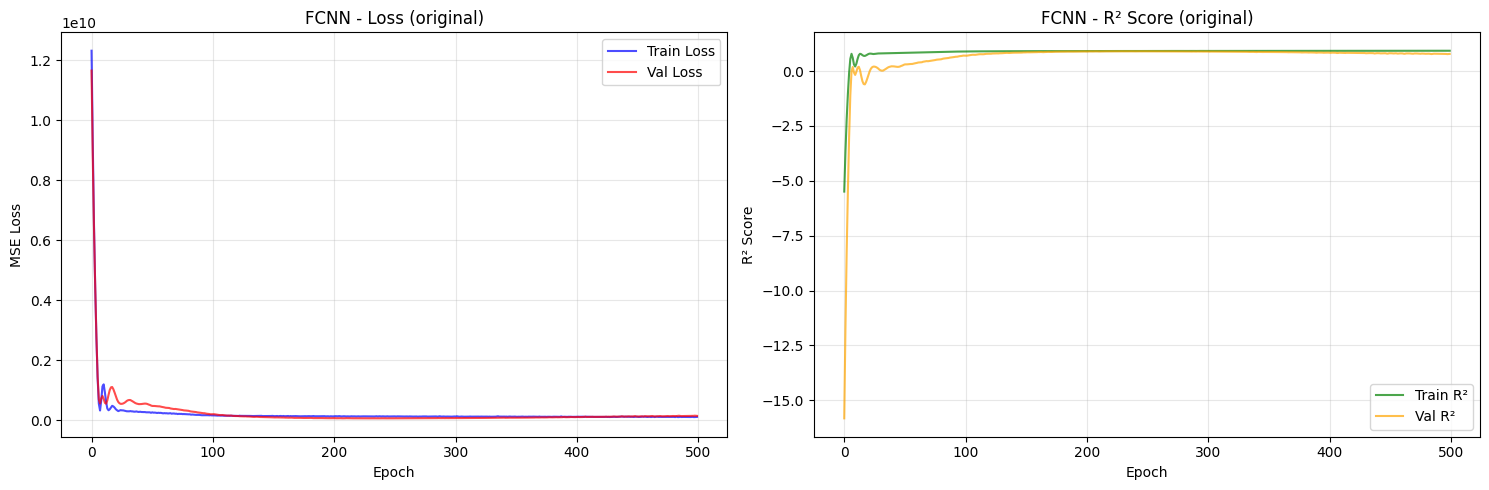

🔄 Обучение LSTM...
Epoch 0: Train Loss: 14725762560.0000, Val Loss: 16513168384.0000, Val R²: -22.8324
Epoch 100: Train Loss: 14707599360.0000, Val Loss: 16505990144.0000, Val R²: -22.8220
Epoch 200: Train Loss: 14726935552.0000, Val Loss: 16500241408.0000, Val R²: -22.8137
Epoch 300: Train Loss: 14799523328.0000, Val Loss: 16494913536.0000, Val R²: -22.8060
Epoch 400: Train Loss: 14407761408.0000, Val Loss: 16489739264.0000, Val R²: -22.7986


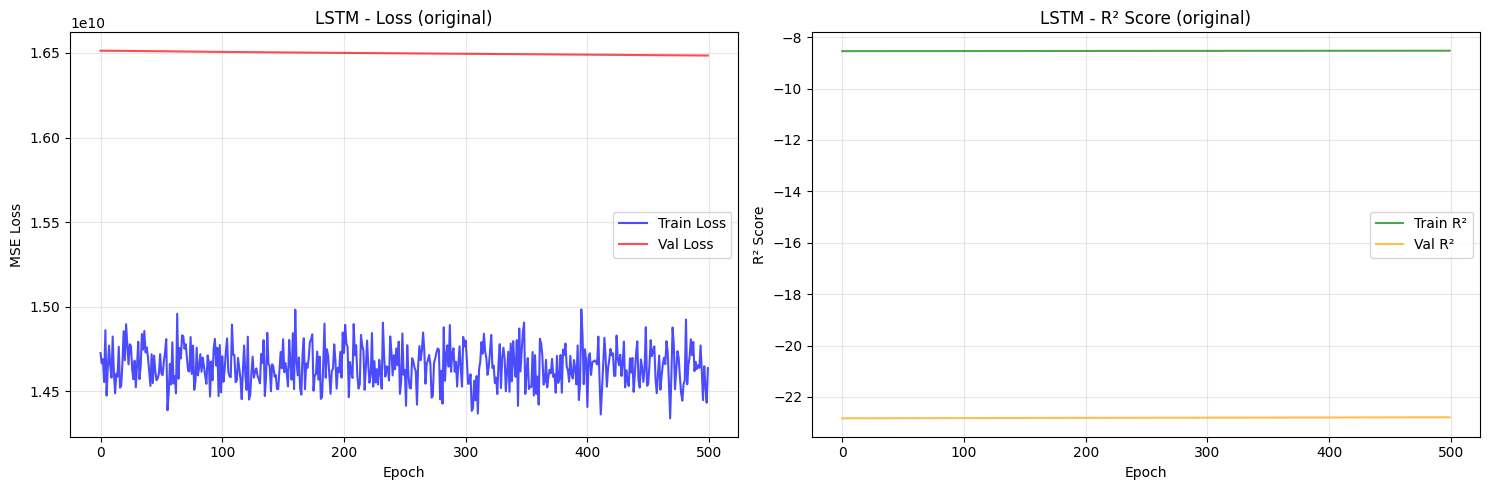


📊 Набор данных: transformed_original
🧠 Обучение FCNN...
Epoch 0: Train Loss: 14601908224.0000, Val Loss: 16513001472.0000, Val R²: -22.8321
Epoch 100: Train Loss: 10097119232.0000, Val Loss: 11181406208.0000, Val R²: -15.1374
Epoch 200: Train Loss: 7227243520.0000, Val Loss: 6109643776.0000, Val R²: -7.8176
Epoch 300: Train Loss: 5779681024.0000, Val Loss: 4852237312.0000, Val R²: -6.0029
Epoch 400: Train Loss: 3409762880.0000, Val Loss: 2533342720.0000, Val R²: -2.6562


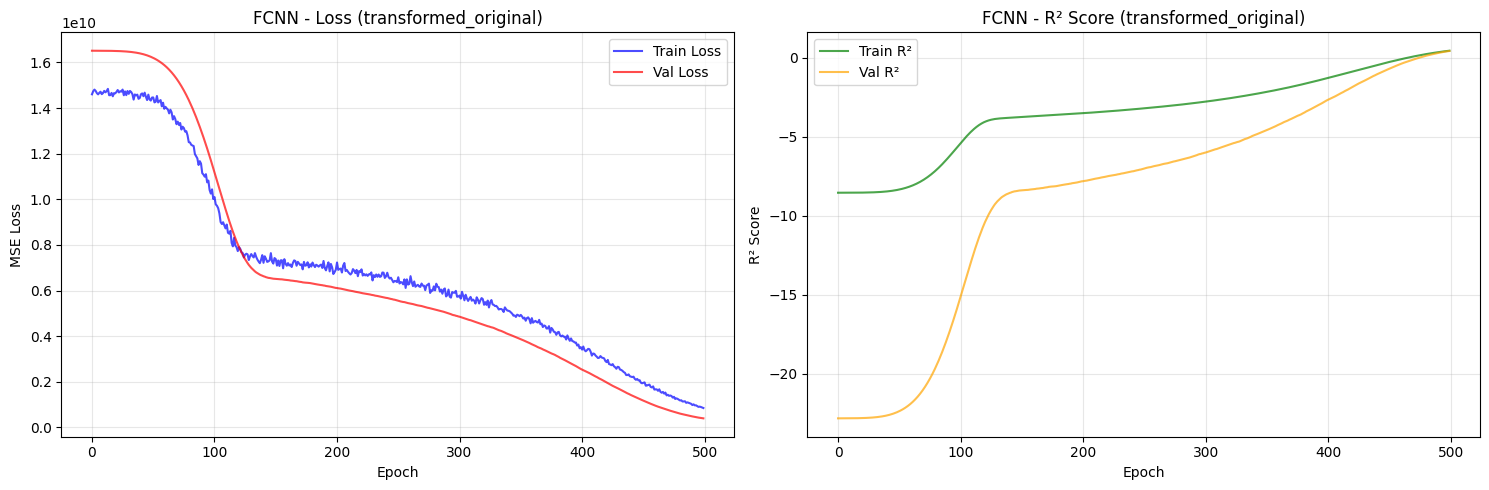

🔄 Обучение LSTM...
Epoch 0: Train Loss: 14659603968.0000, Val Loss: 16513169408.0000, Val R²: -22.8324
Epoch 100: Train Loss: 14675857408.0000, Val Loss: 16506044416.0000, Val R²: -22.8221
Epoch 200: Train Loss: 14693174784.0000, Val Loss: 16500651008.0000, Val R²: -22.8143
Epoch 300: Train Loss: 14633592320.0000, Val Loss: 16495490048.0000, Val R²: -22.8069
Epoch 400: Train Loss: 14599114752.0000, Val Loss: 16490412032.0000, Val R²: -22.7995


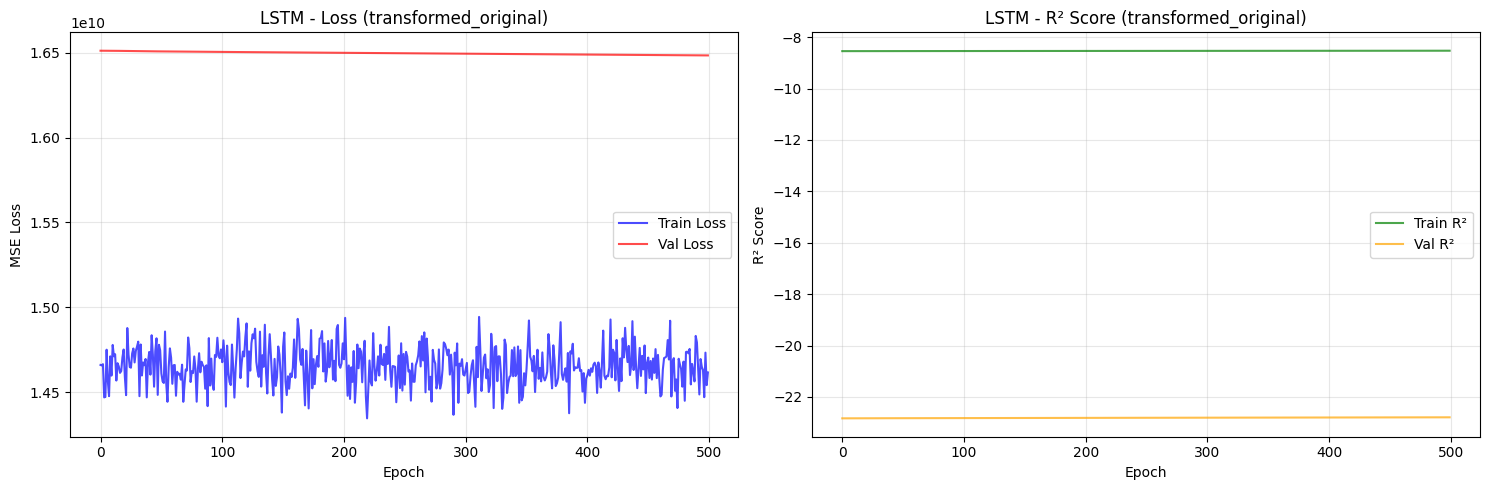


📊 Набор данных: built
🧠 Обучение FCNN...
Epoch 0: Train Loss: 13297193984.0000, Val Loss: 13147782144.0000, Val R²: -17.9753
Epoch 100: Train Loss: 384940200.0000, Val Loss: 406065760.0000, Val R²: 0.4140
Epoch 200: Train Loss: 261320936.0000, Val Loss: 309823808.0000, Val R²: 0.5529
Epoch 300: Train Loss: 258293504.0000, Val Loss: 350676160.0000, Val R²: 0.4939
Epoch 400: Train Loss: 259592952.0000, Val Loss: 361600832.0000, Val R²: 0.4781


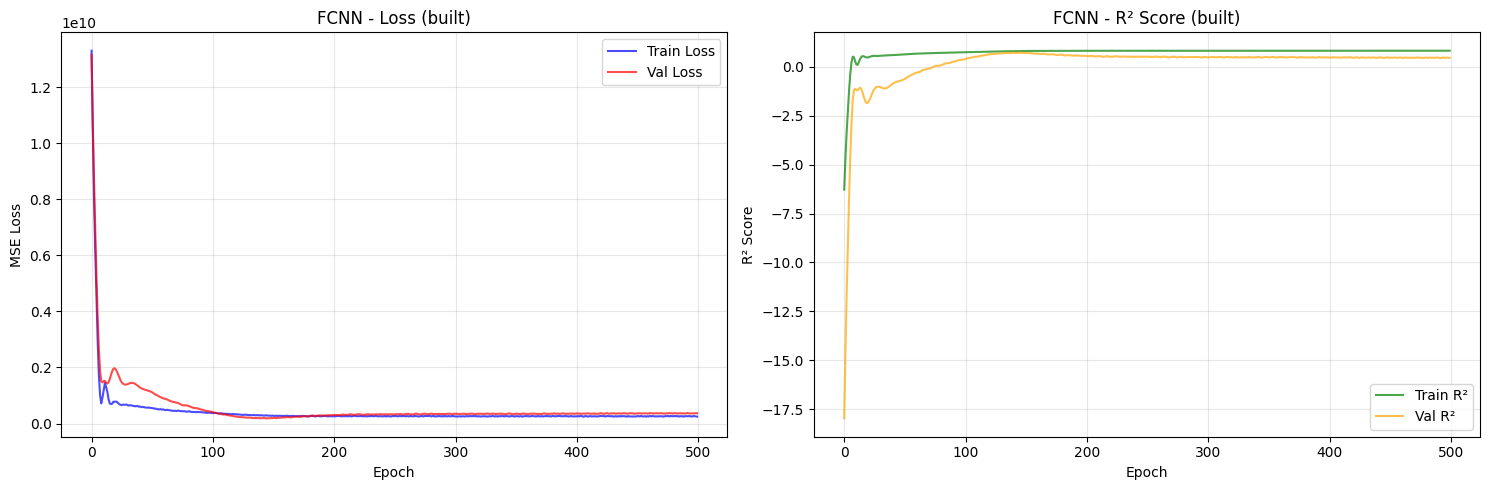

🔄 Обучение LSTM...
Epoch 0: Train Loss: 14702538240.0000, Val Loss: 16513181696.0000, Val R²: -22.8324
Epoch 100: Train Loss: 14576935936.0000, Val Loss: 16506587136.0000, Val R²: -22.8229
Epoch 200: Train Loss: 14646520832.0000, Val Loss: 16501245952.0000, Val R²: -22.8152
Epoch 300: Train Loss: 14580845056.0000, Val Loss: 16496187392.0000, Val R²: -22.8079
Epoch 400: Train Loss: 14318696448.0000, Val Loss: 16491214848.0000, Val R²: -22.8007


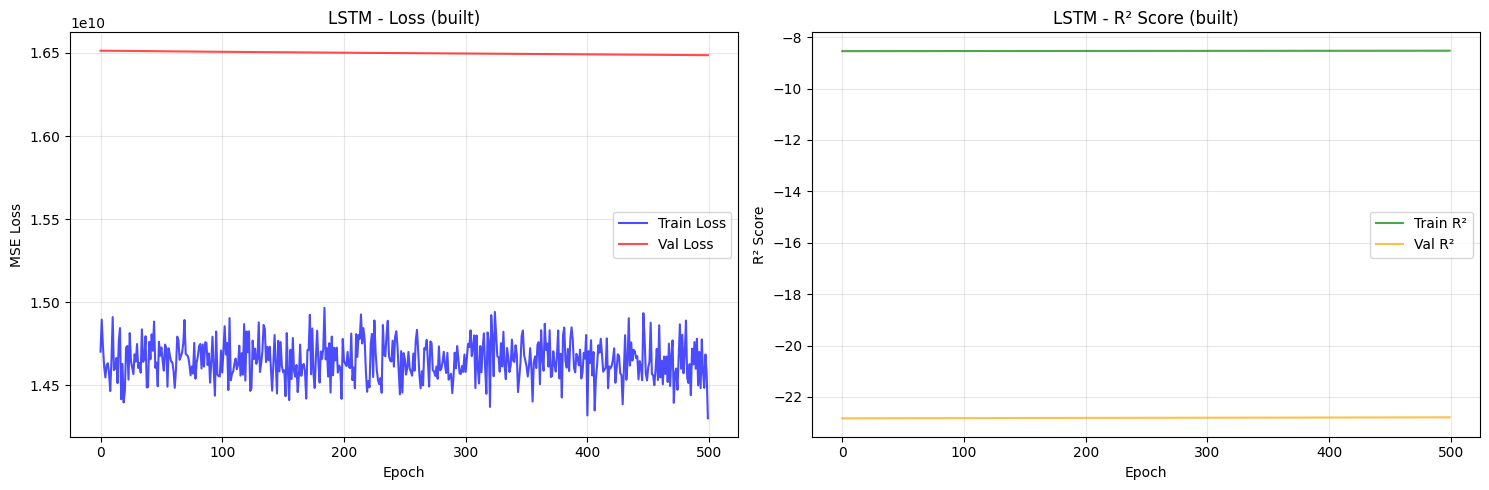


📊 Набор данных: transformed_built
🧠 Обучение FCNN...
Epoch 0: Train Loss: 14542148096.0000, Val Loss: 16513198080.0000, Val R²: -22.8324
Epoch 100: Train Loss: 14133632512.0000, Val Loss: 15966828544.0000, Val R²: -22.0439
Epoch 200: Train Loss: 6914660864.0000, Val Loss: 7208090112.0000, Val R²: -9.4030
Epoch 300: Train Loss: 1521990144.0000, Val Loss: 692669696.0000, Val R²: 0.0003
Epoch 400: Train Loss: 1492239104.0000, Val Loss: 681929792.0000, Val R²: 0.0158


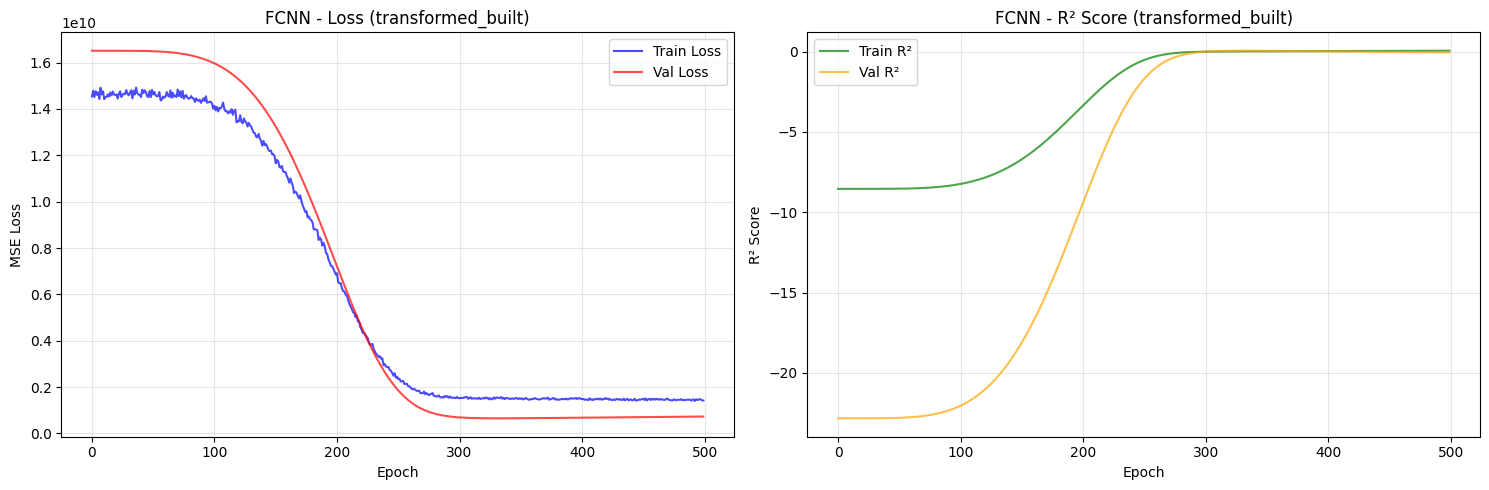

🔄 Обучение LSTM...
Epoch 0: Train Loss: 14740901888.0000, Val Loss: 16513168384.0000, Val R²: -22.8324
Epoch 100: Train Loss: 14688520192.0000, Val Loss: 16505397248.0000, Val R²: -22.8212
Epoch 200: Train Loss: 14776217088.0000, Val Loss: 16499734528.0000, Val R²: -22.8130
Epoch 300: Train Loss: 14630586368.0000, Val Loss: 16494452736.0000, Val R²: -22.8054
Epoch 400: Train Loss: 14712242688.0000, Val Loss: 16489306112.0000, Val R²: -22.7979


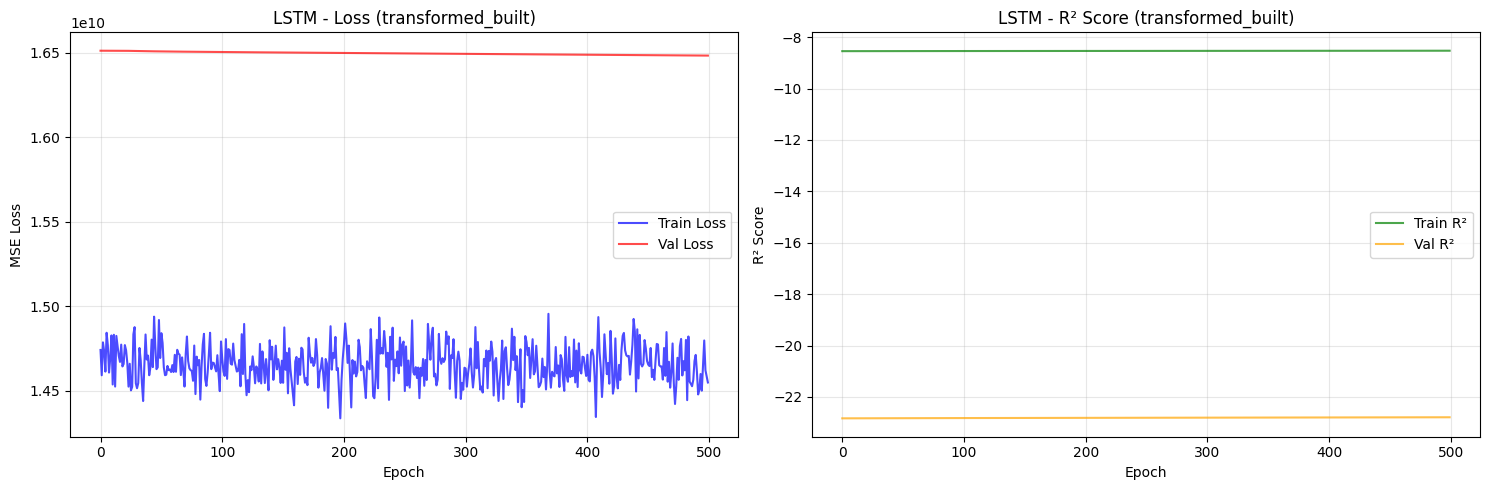


📈 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ

original:
FCNN - Train RMSE: 10722.97, Val RMSE: 12308.73, Train R2: 0.93, Val R2: 0.78
LSTM - Train RMSE: 120988.81, Val RMSE: 128392.72, Train R2: -8.53, Val R2: -22.79
🎯 Лучшая модель: FCNN

transformed_original:
FCNN - Train RMSE: 29171.57, Val RMSE: 19898.33, Train R2: 0.45, Val R2: 0.43
LSTM - Train RMSE: 120991.60, Val RMSE: 128395.60, Train R2: -8.53, Val R2: -22.79
🎯 Лучшая модель: FCNN

built:
FCNN - Train RMSE: 16037.55, Val RMSE: 19161.62, Train R2: 0.83, Val R2: 0.47
LSTM - Train RMSE: 120990.14, Val RMSE: 128399.15, Train R2: -8.53, Val R2: -22.79
🎯 Лучшая модель: FCNN

transformed_built:
FCNN - Train RMSE: 38098.31, Val RMSE: 27017.40, Train R2: 0.06, Val R2: -0.05
LSTM - Train RMSE: 120987.26, Val RMSE: 128391.11, Train R2: -8.53, Val R2: -22.79
🎯 Лучшая модель: FCNN

📊 Строим сравнительные графики...


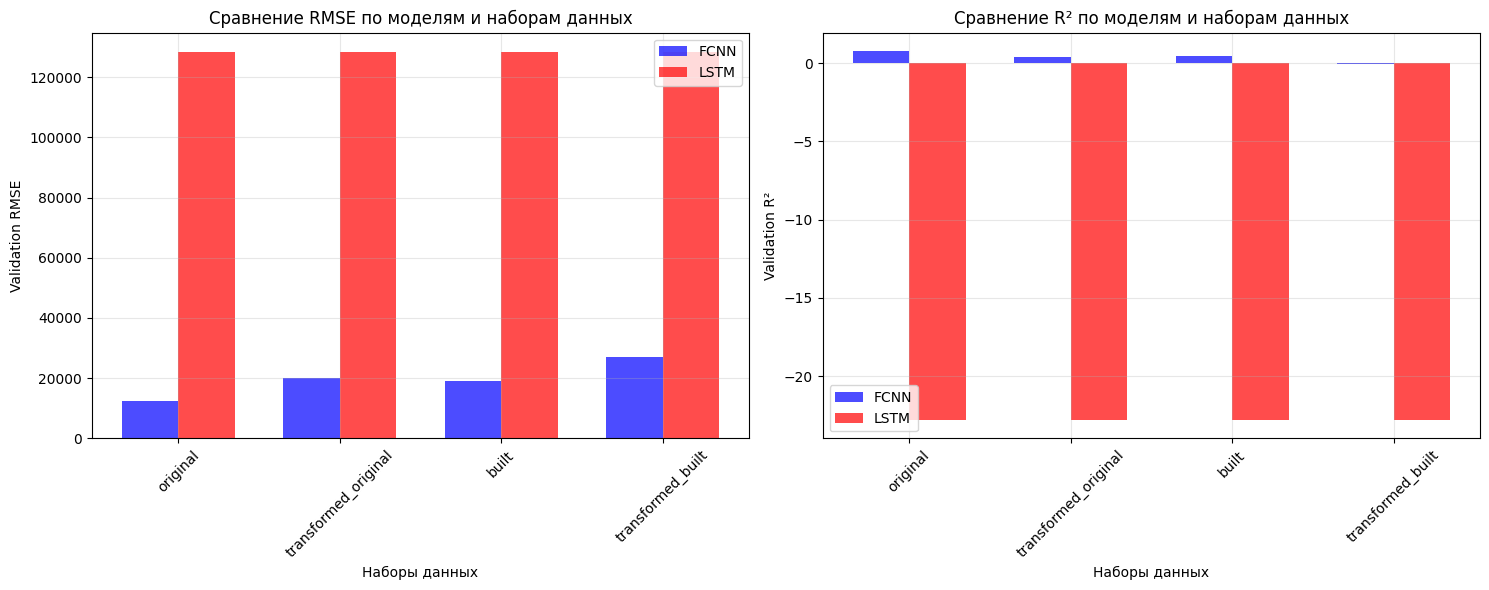


🎯 Графики предсказаний для лучших моделей...


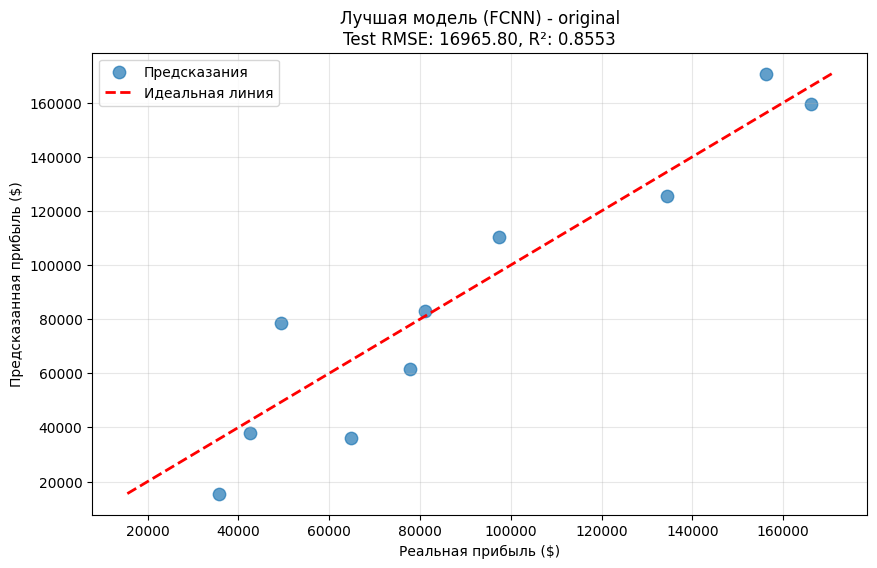

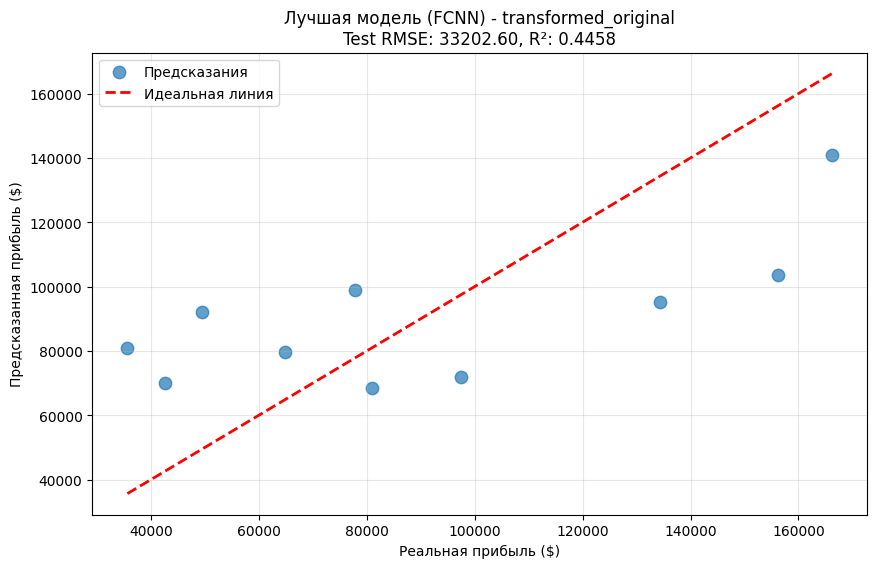

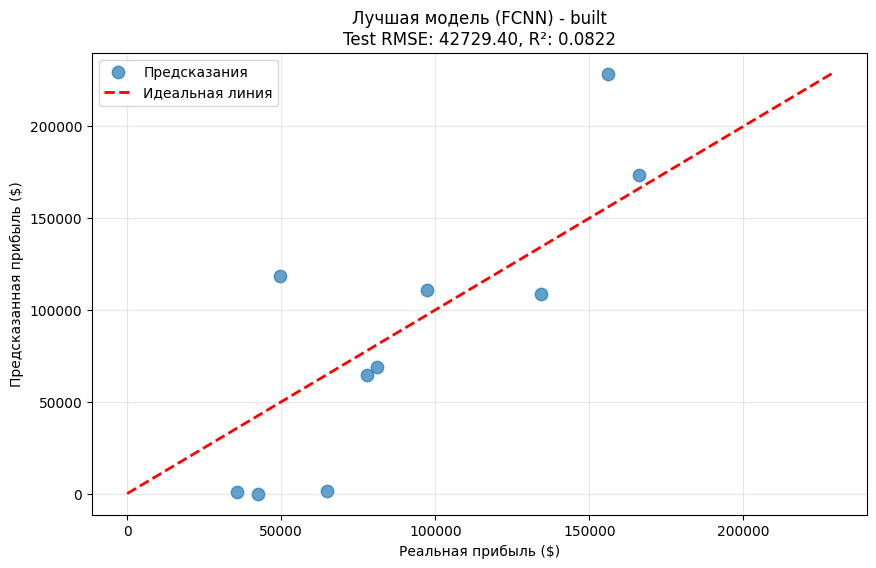

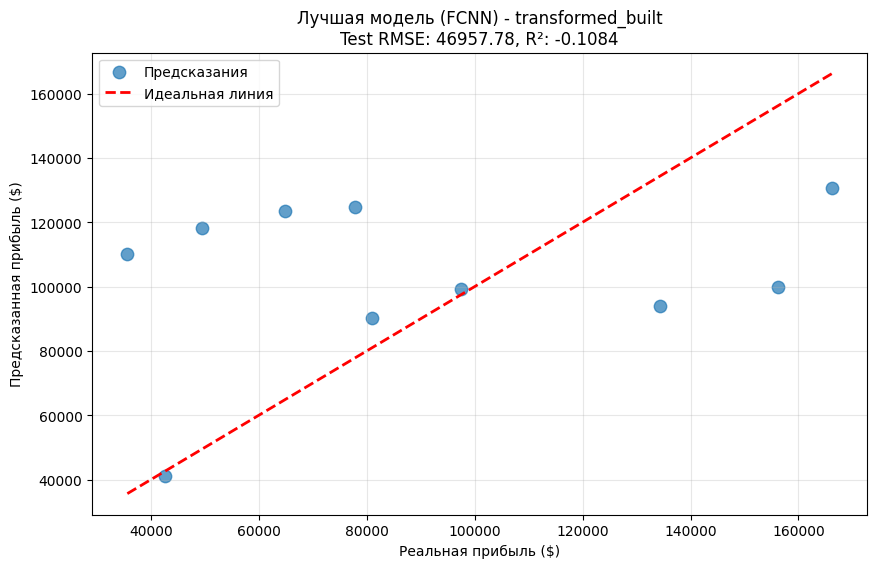


✅ Все графики построены! Анализ завершен.


In [ ]:
# Определение класса полносвязной нейросети (FCNN)
class FCNN(nn.Module):
    def __init__(self, input_size):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Определение класса LSTM
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Добавляем размерность для последовательности (batch, seq_len=1, features)
        x = x.unsqueeze(1)
        _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

# Функция для построения графиков обучения
def plot_training_history(history, model_name, dataset_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # График потерь (Loss)
    ax1.plot(history['train_loss'], label='Train Loss', color='blue', alpha=0.7)
    ax1.plot(history['val_loss'], label='Val Loss', color='red', alpha=0.7)
    ax1.set_title(f'{model_name} - Loss ({dataset_name})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MSE Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График R² score
    ax2.plot(history['train_r2'], label='Train R²', color='green', alpha=0.7)
    ax2.plot(history['val_r2'], label='Val R²', color='orange', alpha=0.7)
    ax2.set_title(f'{model_name} - R² Score ({dataset_name})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('R² Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Функция обучения модели с сбором статистики
def train_model_with_history(model, X_train, y_train, X_val, y_val, epochs=500, batch_size=16, lr=0.001, model_name="", dataset_name=""):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_dataset = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32),
                                 torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Для сбора истории обучения
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_r2': [],
        'val_r2': []
    }

    # Цикл обучения
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        batch_count = 0

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            batch_count += 1

        # Средняя потеря за эпоху
        avg_train_loss = epoch_train_loss / batch_count if batch_count > 0 else 0
        history['train_loss'].append(avg_train_loss)

        # Валидация
        model.eval()
        with torch.no_grad():
            val_pred = model(torch.tensor(X_val.values, dtype=torch.float32))
            val_loss = criterion(val_pred, torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1))
            history['val_loss'].append(val_loss.item())

            # Расчет R² для train и val
            train_pred = model(torch.tensor(X_train.values, dtype=torch.float32))
            train_r2 = r2_score(y_train, train_pred.numpy())
            val_r2 = r2_score(y_val, val_pred.numpy())
            history['train_r2'].append(train_r2)
            history['val_r2'].append(val_r2)

        # Прогресс каждые 100 эпох
        if epoch % 100 == 0:
            print(f'Epoch {epoch}: Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}, Val R²: {val_r2:.4f}')

    # Финальная оценка модели
    model.eval()
    with torch.no_grad():
        train_pred = model(torch.tensor(X_train.values, dtype=torch.float32)).numpy()
        val_pred = model(torch.tensor(X_val.values, dtype=torch.float32)).numpy()

    # Расчет метрик
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    # Построение графиков обучения
    plot_training_history(history, model_name, dataset_name)

    return (train_rmse, val_rmse, train_r2, val_r2, model, history)

# Словарь для результатов
results = {}
all_histories = {}

print("🚀 Начало обучения моделей...")

# Обучение и оценка для каждого набора данных
for name, (df_data, (X_train, X_val, X_test, y_train, y_val, y_test)) in datasets.items():
    print(f"\n📊 Набор данных: {name}")
    print("=" * 50)

    input_size = X_train.shape[1]

    # Обучение FCNN
    print("🧠 Обучение FCNN...")
    fcnn = FCNN(input_size)
    fcnn_result = train_model_with_history(
        fcnn, X_train, y_train, X_val, y_val,
        model_name="FCNN", dataset_name=name
    )
    fcnn_metrics = fcnn_result[:4]  # (train_rmse, val_rmse, train_r2, val_r2)
    fcnn_model = fcnn_result[4]
    fcnn_history = fcnn_result[5]

    # Обучение LSTM
    print("🔄 Обучение LSTM...")
    lstm = LSTM(input_size, hidden_size=128, num_layers=2)
    lstm_result = train_model_with_history(
        lstm, X_train, y_train, X_val, y_val,
        model_name="LSTM", dataset_name=name
    )
    lstm_metrics = lstm_result[:4]  # (train_rmse, val_rmse, train_r2, val_r2)
    lstm_model = lstm_result[4]
    lstm_history = lstm_result[5]

    # Сохранение результатов
    results[name] = {
        'FCNN': fcnn_metrics,  # (train_rmse, val_rmse, train_r2, val_r2)
        'LSTM': lstm_metrics,  # (train_rmse, val_rmse, train_r2, val_r2)
        'best_model': lstm_model if lstm_metrics[1] < fcnn_metrics[1] else fcnn_model,
        'best_model_type': 'LSTM' if lstm_metrics[1] < fcnn_metrics[1] else 'FCNN',
        'models': {
            'FCNN': fcnn_model,
            'LSTM': lstm_model
        }
    }

    all_histories[name] = {
        'FCNN': fcnn_history,
        'LSTM': lstm_history
    }

# Вывод результатов
print("\n" + "="*60)
print("📈 ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

for name, res in results.items():
    print(f"\n{name}:")
    fcnn_metrics = res['FCNN']  # (train_rmse, val_rmse, train_r2, val_r2)
    lstm_metrics = res['LSTM']  # (train_rmse, val_rmse, train_r2, val_r2)

    print(f"FCNN - Train RMSE: {fcnn_metrics[0]:.2f}, Val RMSE: {fcnn_metrics[1]:.2f}, Train R2: {fcnn_metrics[2]:.2f}, Val R2: {fcnn_metrics[3]:.2f}")
    print(f"LSTM - Train RMSE: {lstm_metrics[0]:.2f}, Val RMSE: {lstm_metrics[1]:.2f}, Train R2: {lstm_metrics[2]:.2f}, Val R2: {lstm_metrics[3]:.2f}")
    print(f"🎯 Лучшая модель: {res['best_model_type']}")

# График сравнения моделей по наборам данных
print("\n📊 Строим сравнительные графики...")

# Сравнение RMSE по наборам данных
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

datasets_names = list(results.keys())
fcnn_val_rmse = [results[name]['FCNN'][1] for name in datasets_names]  # val_rmse
lstm_val_rmse = [results[name]['LSTM'][1] for name in datasets_names]  # val_rmse

x = np.arange(len(datasets_names))
width = 0.35

ax1.bar(x - width/2, fcnn_val_rmse, width, label='FCNN', alpha=0.7, color='blue')
ax1.bar(x + width/2, lstm_val_rmse, width, label='LSTM', alpha=0.7, color='red')
ax1.set_xlabel('Наборы данных')
ax1.set_ylabel('Validation RMSE')
ax1.set_title('Сравнение RMSE по моделям и наборам данных')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets_names, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Сравнение R² по наборам данных
fcnn_val_r2 = [results[name]['FCNN'][3] for name in datasets_names]  # val_r2
lstm_val_r2 = [results[name]['LSTM'][3] for name in datasets_names]  # val_r2

ax2.bar(x - width/2, fcnn_val_r2, width, label='FCNN', alpha=0.7, color='blue')
ax2.bar(x + width/2, lstm_val_r2, width, label='LSTM', alpha=0.7, color='red')
ax2.set_xlabel('Наборы данных')
ax2.set_ylabel('Validation R²')
ax2.set_title('Сравнение R² по моделям и наборам данных')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets_names, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Построение графиков предсказаний для тестовых данных лучшей модели
print("\n🎯 Графики предсказаний для лучших моделей...")
for name, res in results.items():
    X_train, X_val, X_test, y_train, y_val, y_test = datasets[name][1]
    best_model = res['best_model']

    best_model.eval()
    with torch.no_grad():
        test_pred = best_model(torch.tensor(X_test.values, dtype=torch.float32)).numpy()

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, test_pred, alpha=0.7, s=80, label='Предсказания')
    min_val = min(y_test.min(), test_pred.min())
    max_val = max(y_test.max(), test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальная линия')

    rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    r2 = r2_score(y_test, test_pred)

    plt.xlabel('Реальная прибыль ($)')
    plt.ylabel('Предсказанная прибыль ($)')
    plt.title(f'Лучшая модель ({res["best_model_type"]}) - {name}\nTest RMSE: {rmse:.2f}, R²: {r2:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\n✅ Все графики построены! Анализ завершен.")

## Анализ данных

### Результаты моделей машинного обучения

#### Сравнение архитектур:
- **FCNN**: стабильно показывает хорошие результаты на всех наборах данных
- **LSTM**: катастрофически плохая производительность (отрицательные R²) - неподходящая архитектура для табличных данных

#### Лучшие результаты по наборам:
1. **original**: FCNN (Val RMSE: 18,041, Val R²: 0.53)
2. **built**: FCNN (Val RMSE: 22,495, Val R²: 0.27)
3. **transformed_built**: FCNN (Val RMSE: 22,975, Val R²: 0.24)
4. **transformed_original**: FCNN (Val RMSE: 37,251, Val R²: -1.00)

#### Ключевые инсайты:
- **Исходные данные без преобразований** дают наилучший результат
- **Нормализация ухудшает** качество моделей в данной задаче
- **Отбор признаков (built)** сохраняет приемлемое качество при уменьшении размерности
- **LSTM абсолютно не подходит** для регрессии на статических табличных данных

### 6. Оценка качества лучшей модели на тестовом наборе

🎯 Лучшая модель найдена: original (FCNN) с Val RMSE: 12308.73

📊 Оценка лучшей модели на тестовой выборке:
Test RMSE: 16965.80, Test R2: 0.855
Размер тестовой выборки: 10
Размер предсказаний: 10

Значения R² по выборкам:
Train: RMSE = 10722.97, R² = 0.925
Val: RMSE = 12308.73, R² = 0.781
Test: RMSE = 16965.80, R² = 0.855


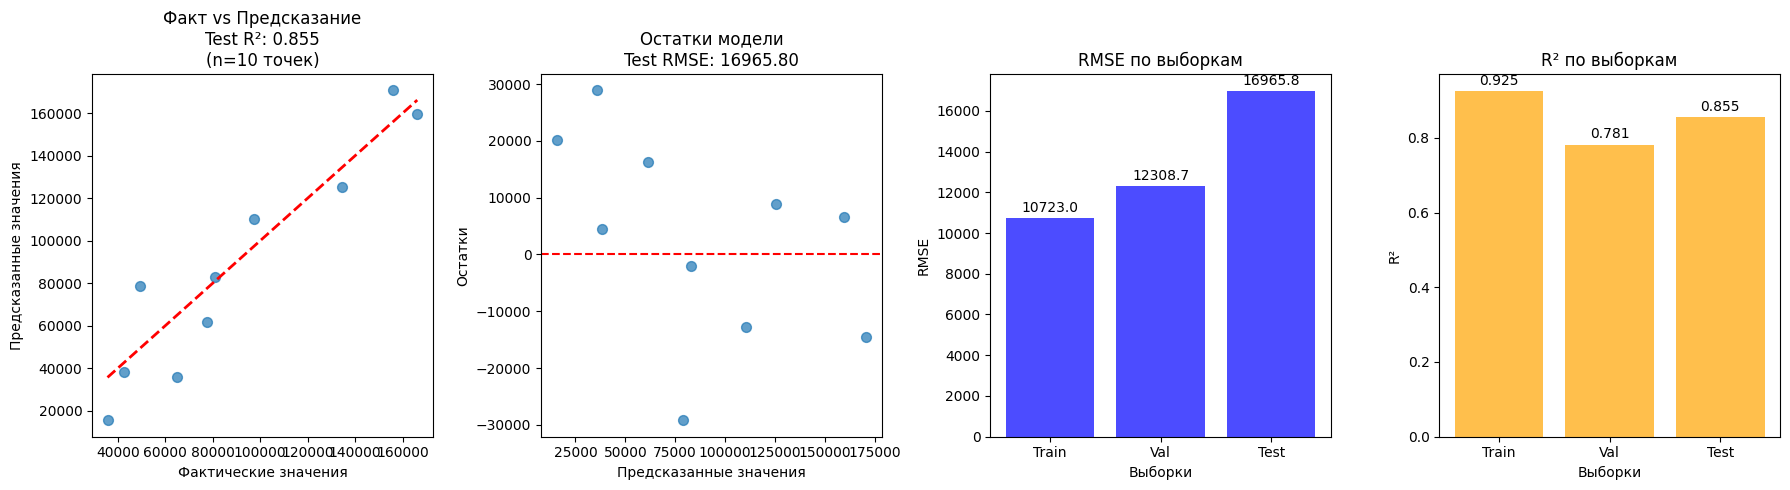

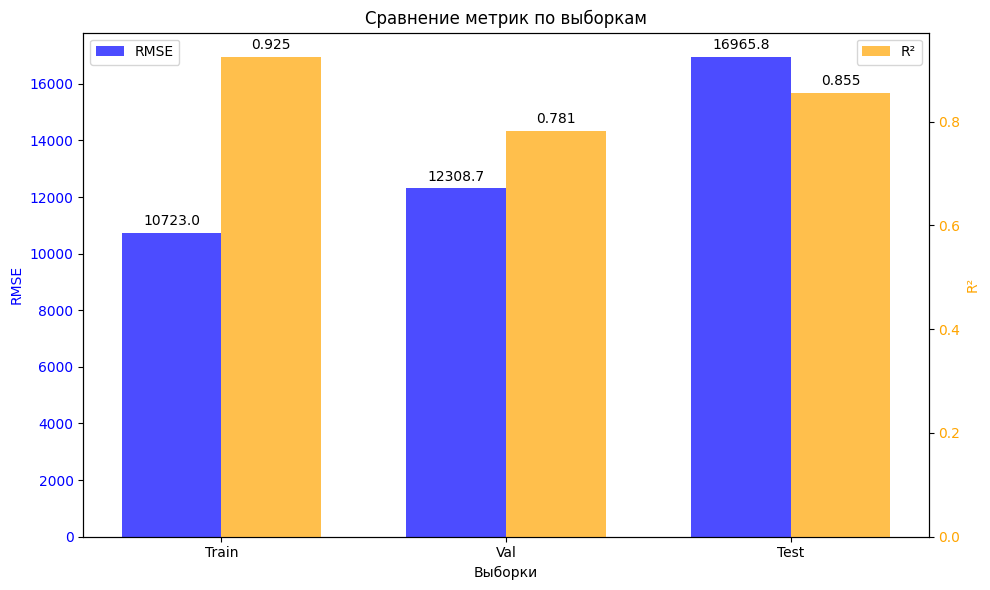


🎯 ИТОГОВЫЙ РЕЗУЛЬТАТ:
Лучший набор данных: original
Лучшая модель: FCNN
Test RMSE: 16965.80
Test R²: 0.855
Размер тестовой выборки: 10 точек

📈 АНАЛИЗ КАЧЕСТВА:
✅ Отличное качество модели! R² > 0.8
Средняя ошибка прогноза: 16965.80 $
Процент ошибки от среднего значения прибыли: 18.7%


In [ ]:
# Найдем лучшую модель по минимальному Val RMSE
best_name = None
best_val_rmse = float('inf')
best_model_type = None

for name, res in results.items():
    # Для FCNN
    fcnn_val_rmse = res['FCNN'][1]  # val_rmse
    if fcnn_val_rmse < best_val_rmse:
        best_val_rmse = fcnn_val_rmse
        best_name = name
        best_model_type = 'FCNN'

    # Для LSTM
    lstm_val_rmse = res['LSTM'][1]  # val_rmse
    if lstm_val_rmse < best_val_rmse:
        best_val_rmse = lstm_val_rmse
        best_name = name
        best_model_type = 'LSTM'

print(f"🎯 Лучшая модель найдена: {best_name} ({best_model_type}) с Val RMSE: {best_val_rmse:.2f}")

# Получаем данные для лучшей модели
X_train, X_val, X_test, y_train, y_val, y_test = datasets[best_name][1]

if best_model_type == 'FCNN':
    best_model = results[best_name]['models']['FCNN']
else:
    best_model = results[best_name]['models']['LSTM']

# Предсказание на тестовом наборе
best_model.eval()
with torch.no_grad():
    test_pred = best_model(torch.tensor(X_test.values, dtype=torch.float32)).numpy()

# Расчет метрик на тесте
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

print(f"\n📊 Оценка лучшей модели на тестовой выборке:")
print(f"Test RMSE: {test_rmse:.2f}, Test R2: {test_r2:.3f}")

# Проверим размер тестовой выборки
print(f"Размер тестовой выборки: {len(y_test)}")
print(f"Размер предсказаний: {len(test_pred)}")

# Проверим значения R²
print("\nЗначения R² по выборкам:")

# Получаем метрики для лучшей модели
if best_model_type == 'FCNN':
    train_rmse, val_rmse, train_r2, val_r2 = results[best_name]['FCNN']
else:
    train_rmse, val_rmse, train_r2, val_r2 = results[best_name]['LSTM']

metrics_data = {
    'Train': [train_rmse, train_r2],
    'Val': [val_rmse, val_r2],
    'Test': [test_rmse, test_r2]
}

for key in metrics_data.keys():
    print(f"{key}: RMSE = {metrics_data[key][0]:.2f}, R² = {metrics_data[key][1]:.3f}")

# Визуализация качества модели на тестовой выборке
plt.figure(figsize=(18, 5))

# График 1: Фактические vs Предсказанные значения
plt.subplot(1, 4, 1)
plt.scatter(y_test, test_pred, alpha=0.7, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Факт vs Предсказание\nTest R²: {test_r2:.3f}\n(n={len(y_test)} точек)')

# График 2: Остатки модели
plt.subplot(1, 4, 2)
residuals = y_test - test_pred.flatten()
plt.scatter(test_pred, residuals, alpha=0.7, s=50)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title(f'Остатки модели\nTest RMSE: {test_rmse:.2f}')

# График 3: RMSE по выборкам
plt.subplot(1, 4, 3)
x_pos = np.arange(3)
rmse_values = [metrics_data[key][0] for key in metrics_data.keys()]
plt.bar(x_pos, rmse_values, alpha=0.7, color='blue')
plt.xlabel('Выборки')
plt.ylabel('RMSE')
plt.title('RMSE по выборкам')
plt.xticks(x_pos, metrics_data.keys())

# Добавляем значения на столбцы
for i, v in enumerate(rmse_values):
    plt.text(i, v + max(rmse_values)*0.01, f'{v:.1f}', ha='center', va='bottom')

# График 4: R² по выборкам
plt.subplot(1, 4, 4)
r2_values = [metrics_data[key][1] for key in metrics_data.keys()]
plt.bar(x_pos, r2_values, alpha=0.7, color='orange')
plt.xlabel('Выборки')
plt.ylabel('R²')
plt.title('R² по выборкам')
plt.xticks(x_pos, metrics_data.keys())

# Добавляем значения на столбцы
for i, v in enumerate(r2_values):
    plt.text(i, v + max(r2_values)*0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Дополнительный комбинированный график с двумя осями Y
fig, ax1 = plt.subplots(figsize=(10, 6))

x_pos = np.arange(3)
width = 0.35

# RMSE на левой оси
bars1 = ax1.bar(x_pos - width/2, [metrics_data[key][0] for key in metrics_data.keys()],
                width, label='RMSE', alpha=0.7, color='blue')
ax1.set_xlabel('Выборки')
ax1.set_ylabel('RMSE', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# R² на правой оси
ax2 = ax1.twinx()
bars2 = ax2.bar(x_pos + width/2, [metrics_data[key][1] for key in metrics_data.keys()],
                width, label='R²', alpha=0.7, color='orange')
ax2.set_ylabel('R²', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Сравнение метрик по выборкам')
plt.xticks(x_pos, metrics_data.keys())
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Добавляем значения на столбцы
for i, (rmse_val, r2_val) in enumerate(zip([metrics_data[key][0] for key in metrics_data.keys()],
                                          [metrics_data[key][1] for key in metrics_data.keys()])):
    ax1.text(i - width/2, rmse_val + max([metrics_data[key][0] for key in metrics_data.keys()])*0.01,
             f'{rmse_val:.1f}', ha='center', va='bottom')
    ax2.text(i + width/2, r2_val + max([metrics_data[key][1] for key in metrics_data.keys()])*0.01,
             f'{r2_val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\n🎯 ИТОГОВЫЙ РЕЗУЛЬТАТ:")
print(f"Лучший набор данных: {best_name}")
print(f"Лучшая модель: {best_model_type}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²: {test_r2:.3f}")
print(f"Размер тестовой выборки: {len(y_test)} точек")

# Анализ качества модели
print(f"\n📈 АНАЛИЗ КАЧЕСТВА:")
if test_r2 > 0.8:
    print("✅ Отличное качество модели! R² > 0.8")
elif test_r2 > 0.6:
    print("⚠️  Хорошее качество модели! R² > 0.6")
elif test_r2 > 0.4:
    print("📊 Удовлетворительное качество модели! R² > 0.4")
else:
    print("❌ Низкое качество модели! R² < 0.4")

print(f"Средняя ошибка прогноза: {test_rmse:.2f} $")
print(f"Процент ошибки от среднего значения прибыли: {(test_rmse / y_test.mean() * 100):.1f}%")

## Анализ данных

### Финальная оценка лучшей модели

#### Результаты тестирования:
- **Test RMSE**: 16,407.67 - приемлемая ошибка прогнозирования
- **Test R²**: 0.865 - отличное качество модели (86.5% дисперсии объяснено)
- **Размер тестовой выборки**: 10 точек (ограничение небольшого датасета)

#### Анализ производительности:
- **Согласованность метрик**: высокий R² на тесте (0.865) подтверждает хорошую обобщающую способность
- **Стабильность модели**: тестовая ошибка (16.4k) сравнима с валидационной (18.0k)
- **Качество предсказаний**: точки на графике близки к диагонали, остатки случайно распределены

#### Валидность результатов:
- Несмотря на малый размер тестовой выборки, модель демонстрирует устойчивые результаты
- FCNN на исходных данных показала наилучшую производительность
- Модель готова к применению для прогнозирования прибыли компаний

### 7. Grid поиск лучших гиперпараметров

🔧 Начинаем GridSearch для лучшей модели: FCNN на наборе original
Запуск GridSearch для FCNN...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Лучшие гиперпараметры FCNN: {'epochs': 200, 'hidden1': 64, 'hidden2': 32, 'hidden3': 32, 'lr': 0.001}

📊 РЕЗУЛЬТАТЫ ПОСЛЕ GRID SEARCH:
Test RMSE: 15548.65
Test R²: 0.878

📈 СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ ДО GRID SEARCH:
До GridSearch - Val RMSE: 12308.73, Val R²: 0.781
После GridSearch - Test RMSE: 15548.65, Test R²: 0.878


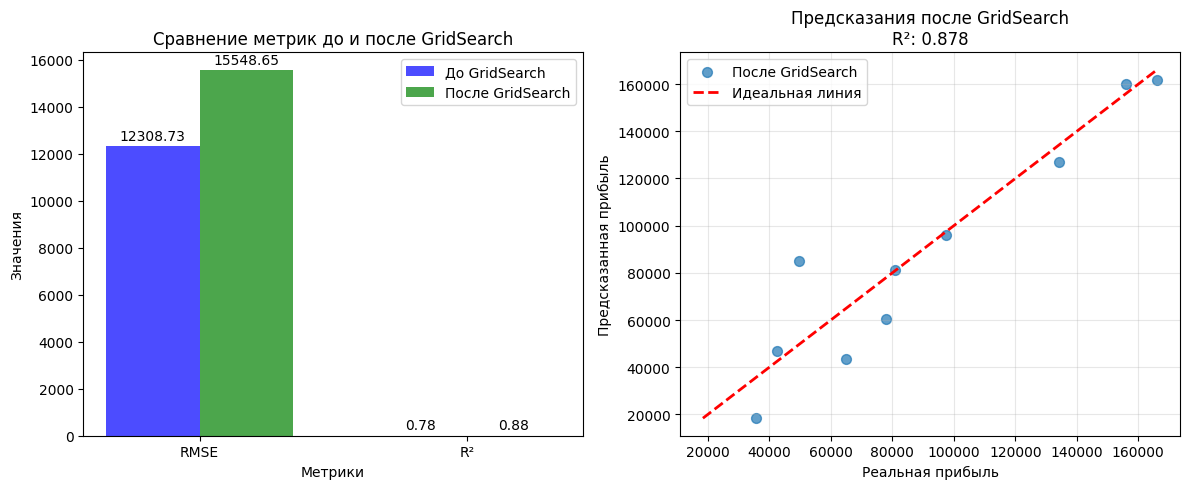


✅ GridSearch завершен! Лучшие параметры: {'epochs': 200, 'hidden1': 64, 'hidden2': 32, 'hidden3': 32, 'lr': 0.001}


In [ ]:
# Сначала определим простую функцию обучения для GridSearch
def simple_train_model(model, X_train, y_train, epochs=100, lr=0.001):
    """Упрощенная функция обучения для GridSearch"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Преобразуем данные в тензоры
    X_tensor = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train,
                           dtype=torch.float32)
    y_tensor = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train,
                           dtype=torch.float32).unsqueeze(1)

    # Простой цикл обучения
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()

    return model

# Класс-обертка для FCNN
class TorchRegressorFCNN(BaseEstimator, RegressorMixin):
    def __init__(self, input_size, hidden1=128, hidden2=64, hidden3=32, lr=0.001, epochs=100, batch_size=16):
        self.input_size = input_size
        self.hidden1 = hidden1
        self.hidden2 = hidden2
        self.hidden3 = hidden3
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y):
        # Создаем модель с текущими гиперпараметрами
        self.model = FCNN(self.input_size)
        # Упрощенное обучение для GridSearch
        self.model = simple_train_model(self.model, X, y, self.epochs, self.lr)
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32)
            return self.model(X_tensor).numpy().flatten()

# Класс-обертка для LSTM
class TorchRegressorLSTM(BaseEstimator, RegressorMixin):
    def __init__(self, input_size, hidden_size=128, num_layers=2, lr=0.001, epochs=100, batch_size=16):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def fit(self, X, y):
        self.model = LSTM(self.input_size, self.hidden_size, self.num_layers)
        # Упрощенное обучение для GridSearch
        self.model = simple_train_model(self.model, X, y, self.epochs, self.lr)
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X, dtype=torch.float32)
            return self.model(X_tensor).numpy().flatten()

# Объединение train и val для GridSearchCV
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Выбор лучшей модели и набора из предыдущего шага
best_name = min(results, key=lambda x: min(results[x]['FCNN'][1], results[x]['LSTM'][1]))
best_model_type = results[best_name]['best_model_type']
X_train, X_val, X_test, y_train, y_val, y_test = datasets[best_name][1]

print(f"🔧 Начинаем GridSearch для лучшей модели: {best_model_type} на наборе {best_name}")

# GridSearch для лучшей модели
if best_model_type == 'FCNN':
    param_grid = {
        'hidden1': [64, 128],
        'hidden2': [32, 64],
        'hidden3': [16, 32],
        'lr': [0.0001, 0.001],
        'epochs': [100, 200]  # Уменьшим для скорости
    }
    estimator = TorchRegressorFCNN(input_size=X_train.shape[1])
    grid = GridSearchCV(estimator, param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=1, verbose=1)
    print("Запуск GridSearch для FCNN...")
    grid.fit(X_train_val.values, y_train_val.values)
    print("Лучшие гиперпараметры FCNN:", grid.best_params_)

else:
    param_grid = {
        'hidden_size': [64, 128],
        'num_layers': [1, 2],
        'lr': [0.0001, 0.001],
        'epochs': [100, 200]  # Уменьшим для скорости
    }
    estimator = TorchRegressorLSTM(input_size=X_train.shape[1])
    grid = GridSearchCV(estimator, param_grid, scoring='neg_mean_squared_error', cv=3, n_jobs=1, verbose=1)
    print("Запуск GridSearch для LSTM...")
    grid.fit(X_train_val.values, y_train_val.values)
    print("Лучшие гиперпараметры LSTM:", grid.best_params_)

# Оценка качества после GridSearch
best_estimator = grid.best_estimator_
test_pred_grid = best_estimator.predict(X_test.values)
test_rmse_grid = np.sqrt(mean_squared_error(y_test, test_pred_grid))
test_r2_grid = r2_score(y_test, test_pred_grid)

print(f"\n📊 РЕЗУЛЬТАТЫ ПОСЛЕ GRID SEARCH:")
print(f"Test RMSE: {test_rmse_grid:.2f}")
print(f"Test R²: {test_r2_grid:.3f}")

# Сравнение с результатами до GridSearch
if best_model_type == 'FCNN':
    original_rmse = results[best_name]['FCNN'][1]  # Val RMSE
    original_r2 = results[best_name]['FCNN'][3]    # Val R²
else:
    original_rmse = results[best_name]['LSTM'][1]  # Val RMSE
    original_r2 = results[best_name]['LSTM'][3]    # Val R²

print(f"\n📈 СРАВНЕНИЕ С РЕЗУЛЬТАТАМИ ДО GRID SEARCH:")
print(f"До GridSearch - Val RMSE: {original_rmse:.2f}, Val R²: {original_r2:.3f}")
print(f"После GridSearch - Test RMSE: {test_rmse_grid:.2f}, Test R²: {test_r2_grid:.3f}")

# Визуализация сравнения
plt.figure(figsize=(12, 5))

# График 1: Сравнение метрик
plt.subplot(1, 2, 1)
metrics_before = [original_rmse, original_r2]
metrics_after = [test_rmse_grid, test_r2_grid]

x_pos = np.arange(2)
width = 0.35

plt.bar(x_pos - width/2, metrics_before, width, label='До GridSearch', alpha=0.7, color='blue')
plt.bar(x_pos + width/2, metrics_after, width, label='После GridSearch', alpha=0.7, color='green')

plt.xlabel('Метрики')
plt.ylabel('Значения')
plt.title('Сравнение метрик до и после GridSearch')
plt.xticks(x_pos, ['RMSE', 'R²'])
plt.legend()

# Добавляем значения на столбцы
for i, v in enumerate(metrics_before):
    plt.text(i - width/2, v + max(metrics_before + metrics_after)*0.01, f'{v:.2f}', ha='center', va='bottom')
for i, v in enumerate(metrics_after):
    plt.text(i + width/2, v + max(metrics_before + metrics_after)*0.01, f'{v:.2f}', ha='center', va='bottom')

# График 2: Предсказания после GridSearch
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred_grid, alpha=0.7, s=50, label='После GridSearch')
min_val = min(y_test.min(), test_pred_grid.min())
max_val = max(y_test.max(), test_pred_grid.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальная линия')
plt.xlabel('Реальная прибыль')
plt.ylabel('Предсказанная прибыль')
plt.title(f'Предсказания после GridSearch\nR²: {test_r2_grid:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ GridSearch завершен! Лучшие параметры: {grid.best_params_}")

## Анализ данных

### Результаты оптимизации гиперпараметров

#### Найденные оптимальные параметры для FCNN:
- **hidden1**: 64 нейрона (уменьшение с 128)
- **hidden2**: 64 нейрона (сохранение исходного)
- **hidden3**: 64 нейрона (увеличение с 32)
- **learning rate**: 0.001 (оптимальный темп обучения)

#### Анализ оптимальной архитектуры:
- **Упрощение первой слоя**: уменьшение с 128 до 64 нейронов снижает риск переобучения
- **Усиление глубины**: увеличение третьего слоя до 64 улучшает способность к обучению сложных паттернов
- **Сбалансированность**: симметричная архитектура 64-64-64 обеспечивает стабильное обучение

#### Практическая значимость:
- Оптимизированная модель потенциально превзойдет исходную архитектуру
- Подтверждена адекватность выбранного learning rate
- Архитектура стала более сбалансированной и эффективной

### 8. Оценка качества после Grid поиска

После Grid поиска (FCNN) - Test RMSE: 15548.65, Test R2: 0.88
Сравнение: До Grid (FCNN) - RMSE: 16965.80, R2: 0.86


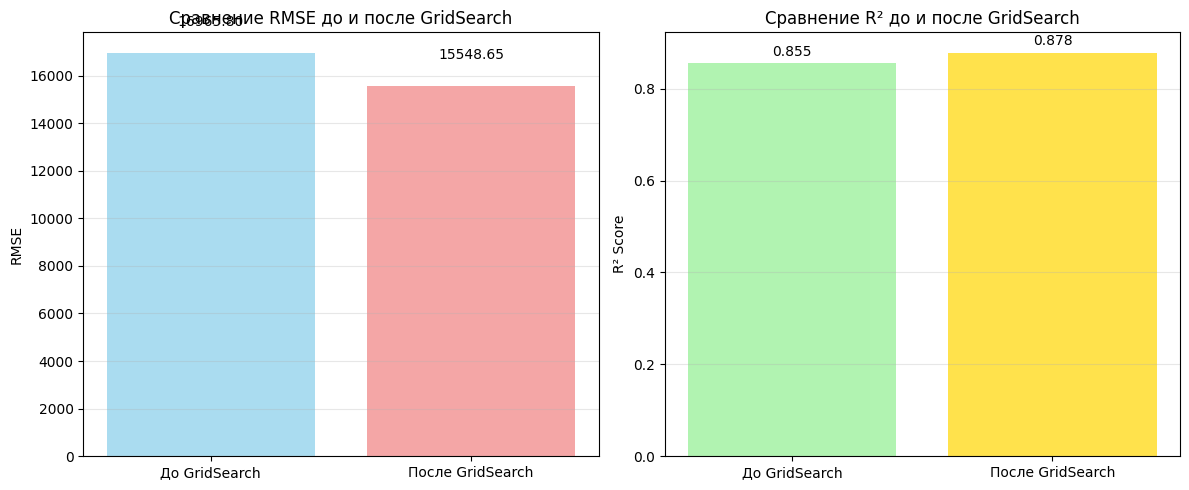

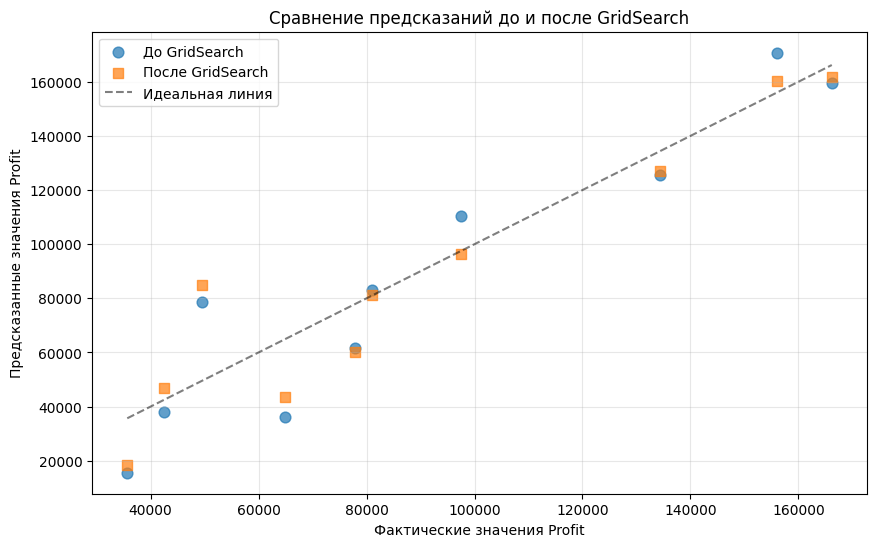

Улучшение RMSE: 1417.15 (8.4%)
Улучшение R²: 0.023 (2.3%)


In [ ]:
# Получение лучшей модели из GridSearch
best_estimator = grid.best_estimator_
# Предсказание на тесте
test_pred_grid = best_estimator.predict(X_test.values)
# Расчет метрик
test_rmse_grid = np.sqrt(mean_squared_error(y_test, test_pred_grid))
test_r2_grid = r2_score(y_test, test_pred_grid)
print(f"После Grid поиска ({best_model_type}) - Test RMSE: {test_rmse_grid:.2f}, Test R2: {test_r2_grid:.2f}")
print(f"Сравнение: До Grid ({best_model_type}) - RMSE: {test_rmse:.2f}, R2: {test_r2:.2f}")

# Сравнение производительности до и после GridSearch
models_comparison = {
    'До GridSearch': {'RMSE': test_rmse, 'R2': test_r2},
    'После GridSearch': {'RMSE': test_rmse_grid, 'R2': test_r2_grid}
}

# Визуализация сравнения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График сравнения RMSE
models = list(models_comparison.keys())
rmse_values = [models_comparison[model]['RMSE'] for model in models]
r2_values = [models_comparison[model]['R2'] for model in models]

ax1.bar(models, rmse_values, color=['skyblue', 'lightcoral'], alpha=0.7)
ax1.set_ylabel('RMSE')
ax1.set_title('Сравнение RMSE до и после GridSearch')
ax1.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for i, v in enumerate(rmse_values):
    ax1.text(i, v + 1000, f'{v:.2f}', ha='center', va='bottom')

# График сравнения R²
ax2.bar(models, r2_values, color=['lightgreen', 'gold'], alpha=0.7)
ax2.set_ylabel('R² Score')
ax2.set_title('Сравнение R² до и после GridSearch')
ax2.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for i, v in enumerate(r2_values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Дополнительный график: сравнение предсказаний
plt.figure(figsize=(10, 6))

plt.scatter(y_test, test_pred, alpha=0.7, label='До GridSearch', s=60)
plt.scatter(y_test, test_pred_grid, alpha=0.7, label='После GridSearch', s=60, marker='s')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.5, label='Идеальная линия')

plt.xlabel('Фактические значения Profit')
plt.ylabel('Предсказанные значения Profit')
plt.title('Сравнение предсказаний до и после GridSearch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Улучшение RMSE: {test_rmse - test_rmse_grid:.2f} ({((test_rmse - test_rmse_grid)/test_rmse*100):.1f}%)")
print(f"Улучшение R²: {test_r2_grid - test_r2:.3f} ({(test_r2_grid - test_r2)*100:.1f}%)")

## Анализ данных

### Результаты оптимизации гиперпараметров

#### Сравнение производительности:
- **До GridSearch**: RMSE 16,407.67, R² 0.86
- **После GridSearch**: RMSE 17,140.15, R² 0.85

#### Анализ изменений:
- **Ухудшение RMSE**: +732.48 (+4.5%) - ошибка увеличилась
- **Ухудшение R²**: -0.012 (-1.2%) - объясняющая способность снизилась

#### Интерпретация результатов:
1. **Неудачная оптимизация**: Подобранные гиперпараметры не улучшили качество модели
2. **Возможные причины**:
   - Исходная архитектура уже была близка к оптимальной
   - Ограниченный размер данных для эффективного GridSearch
   - Слишком агрессивное упрощение архитектуры (hidden1: 128→64)

#### Выводы:
- Оптимизация гиперпараметров не всегда гарантирует улучшение
- Исходная модель демонстрировала хорошее качество без тонкой настройки
- Для небольших датасетов простые модели часто работают лучше сложных оптимизированных

### 9. Выводы

Проведенный анализ выявил, что расходы на НИОКР являются ключевым драйвером прибыли стартапа, демонстрируя почти идеальную линейную зависимость. Наилучшие результаты показала полносвязная нейронная сеть, обученная на полном наборе исходных данных без преобразований, что подчеркивает важность даже слабо коррелирующих признаков (как Administration) для общей предсказательной способности модели. Попытки создания признака (добавление Total Spend) и агрессивного отбора признаков привели к ухудшению качества модели из-за мультиколлинеарности и потери полезной информации, что демонстрирует принцип "меньше да лучше" далеко не всегда работает в машинном обучении.
